In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet18

In [36]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cuda


In [38]:
class CarlaDataset(Dataset):

    def __init__(self, image_dir, csv_file, transform=None, label_col="has_pedestrian"):
        self.image_dir = image_dir
        self.labels = pd.read_csv(csv_file)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = int(row["frame"])

        image_path = os.path.join(
            self.image_dir,
            f"{frame:06d}.jpga
        )

        image = Image.open(image_path).convert("RGB")

        label = float(row[self.label_col])

        if self.transform:
            image = self.transform(image)

        return image, label

In [39]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [40]:
id_dir = "data/test/rgb-front"
id_labels = "data/test/labels.csv"

test_dataset = CarlaDataset(
    id_dir,
    id_labels,
    transform=transform,
    label_col="has_pedestrian"   # change per model
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [41]:
ped_model = resnet18(weights=None)
ped_model.fc = nn.Linear(ped_model.fc.in_features, 1)

ped_model.load_state_dict(torch.load("ped_model_v2.pth", map_location=device))

ped_model = ped_model.to(device)
ped_model.eval()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2668\322882075.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ped_model.load_state_dict(torch.load("ped_model_v2.pth", map_lo

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [42]:
def get_predictions(model, loader):

    probs_list = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)

            outputs = model(images).squeeze()

            probs = torch.sigmoid(outputs)

            probs_list.extend(probs.cpu().numpy())
            labels_list.extend(labels.numpy())

    return np.array(probs_list), np.array(labels_list)

In [43]:
def compute_ece(probs, labels, n_bins=10):

    probs = np.array(probs)
    labels = np.array(labels).astype(int)

    preds = (probs >= 0.5).astype(int)

    bins = np.linspace(0, 1, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):

        lower, upper = bins[i], bins[i+1]

        if i == n_bins - 1:
            mask = (probs >= lower) & (probs <= upper)
        else:
            mask = (probs >= lower) & (probs < upper)

        if np.sum(mask) == 0:
            continue

        conf = np.mean(probs[mask])
        acc = np.mean(preds[mask] == labels[mask])

        weight = len(probs[mask]) / len(probs)

        ece += weight * abs(conf - acc)

    return ece

In [44]:
def reliability_diagram(probs, labels, title, n_bins=10):

    probs = np.array(probs)
    labels = np.array(labels).astype(int)
    preds = (probs >= 0.5).astype(int)

    bins = np.linspace(0, 1, n_bins + 1)

    confidences = []
    accuracies = []

    for i in range(n_bins):

        lower, upper = bins[i], bins[i+1]

        if i == n_bins - 1:
            mask = (probs >= lower) & (probs <= upper)
        else:
            mask = (probs >= lower) & (probs < upper)

        if np.sum(mask) == 0:
            continue

        confidences.append(np.mean(probs[mask]))
        accuracies.append(np.mean(preds[mask] == labels[mask]))

    plt.figure(figsize=(6,6))

    plt.plot([0,1], [0,1], "--", label="Perfect")

    plt.plot(confidences, accuracies, marker="o")

    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid()
    plt.legend()
    plt.show()

In [34]:
import numpy as np

def compute_ece(probs, labels, n_bins=10):

    probs = np.array(probs)
    labels = np.array(labels)

    preds = (probs >= 0.5).astype(int)
    labels = labels.astype(int)

    bins = np.linspace(0, 1, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):

        # bin range
        lower, upper = bins[i], bins[i + 1]

        # include last bin edge properly
        if i == n_bins - 1:
            mask = (probs >= lower) & (probs <= upper)
        else:
            mask = (probs >= lower) & (probs < upper)

        if np.sum(mask) == 0:
            continue

        bin_probs = probs[mask]
        bin_preds = preds[mask]
        bin_labels = labels[mask]

        # confidence = mean predicted probability
        confidence = np.mean(bin_probs)

        # accuracy = mean correct predictions
        accuracy = np.mean(bin_preds == bin_labels)

        weight = len(bin_probs) / len(probs)

        ece += weight * abs(confidence - accuracy)

    return ece

In [45]:
def reliability_diagram(probs, labels, title, n_bins=10):

    probs = np.array(probs)
    labels = np.array(labels).astype(int)
    preds = (probs >= 0.5).astype(int)

    bins = np.linspace(0, 1, n_bins + 1)

    confidences = []
    accuracies = []

    for i in range(n_bins):

        lower, upper = bins[i], bins[i+1]

        if i == n_bins - 1:
            mask = (probs >= lower) & (probs <= upper)
        else:
            mask = (probs >= lower) & (probs < upper)

        if np.sum(mask) == 0:
            continue

        confidences.append(np.mean(probs[mask]))
        accuracies.append(np.mean(preds[mask] == labels[mask]))

    plt.figure(figsize=(6,6))

    plt.plot([0,1], [0,1], "--", label="Perfect")

    plt.plot(confidences, accuracies, marker="o")

    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid()
    plt.legend()
    plt.show()

ECE: 0.7148425148629269


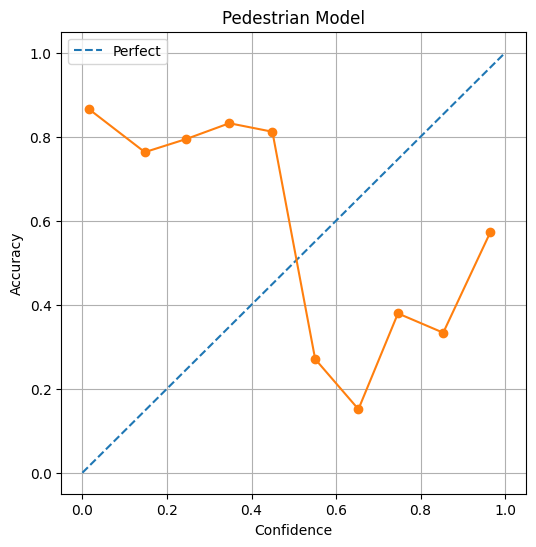

In [46]:
test_dataset = CarlaDataset(
    id_dir,
    id_labels,
    transform=transform,
    label_col="has_pedestrian"
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

probs, labels = get_predictions(ped_model, test_loader)
Q
print("ECE:", compute_ece(probs, labels))

reliability_diagram(probs, labels, "Pedestrian Model")

In [48]:
vehicle_dataset = CarlaDataset(
    id_dir,
    id_labels,
    transform=transform,
    label_col="has_vehicle"
)

vehicle_loader = DataLoader(vehicle_dataset, batch_size=32, shuffle=False)

In [50]:
vehicle_model = resnet18(weights=None)
vehicle_model.fc = nn.Linear(vehicle_model.fc.in_features, 1)

checkpoint = torch.load("vehicle_model.pth", map_location=device)
vehicle_model.load_state_dict(checkpoint)

vehicle_model = vehicle_model.to(device)
vehicle_model.eval()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2668\1998558154.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("vehicle_model.pth", map_location=devi

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Vehicle ECE: 0.18155458019942874


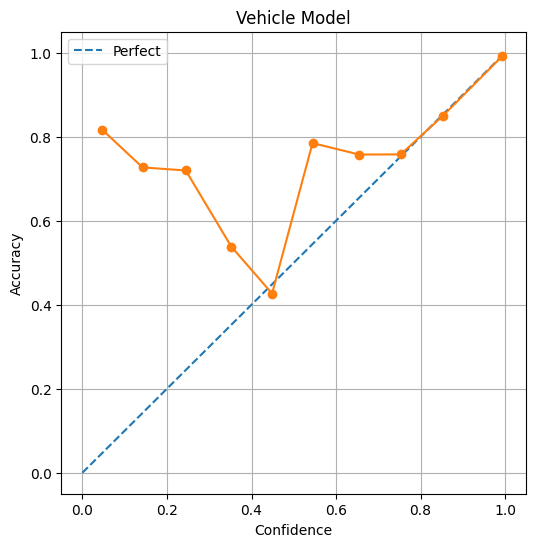

In [51]:
vehicle_probs, vehicle_labels = get_predictions(vehicle_model, vehicle_loader)

print("Vehicle ECE:", compute_ece(vehicle_probs, vehicle_labels))

reliability_diagram(
    vehicle_probs,
    vehicle_labels,
    "Vehicle Model"
)

In [52]:
traffic_dataset = CarlaDataset(
    id_dir,
    id_labels,
    transform=transform,
    label_col="has_traffic_light"
)

traffic_loader = DataLoader(traffic_dataset, batch_size=32, shuffle=False)

In [53]:
traffic_model = resnet18(weights=None)
traffic_model.fc = nn.Linear(traffic_model.fc.in_features, 1)

traffic_checkpoint = torch.load("traffic_light_model.pth", map_location=device)
traffic_model.load_state_dict(traffic_checkpoint)

traffic_model = traffic_model.to(device)
traffic_model.eval()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2668\3749839313.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  traffic_checkpoint = torch.load("traffic_light_model.pth", map

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Traffic Light ECE: 0.2619261079460072


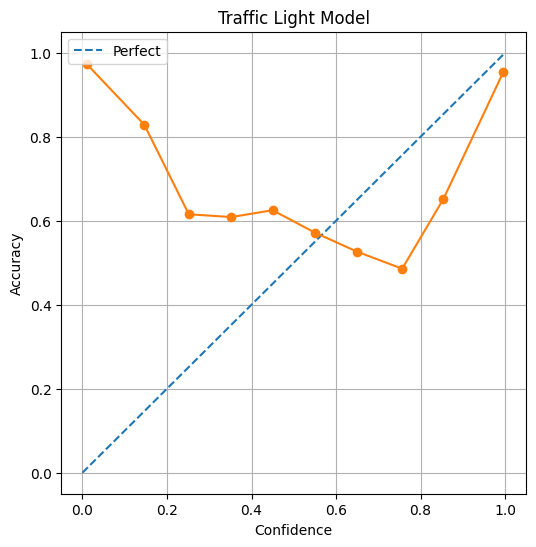

In [54]:
traffic_probs, traffic_labels = get_predictions(traffic_model, traffic_loader)

print("Traffic Light ECE:", compute_ece(traffic_probs, traffic_labels))

reliability_diagram(
    traffic_probs,
    traffic_labels,
    "Traffic Light Model"
)

In [55]:
class ModelWithTemperature(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.0)

    def forward(self, x):
        logits = self.model(x).squeeze()
        return logits / self.temperature

In [56]:
def nll_loss(logits, labels):
    return nn.functional.binary_cross_entropy_with_logits(
        logits,
        labels
    )

In [57]:
def optimize_temperature(model, loader, device):
    model = ModelWithTemperature(model).to(device)

    optimizer = torch.optim.LBFGS([model.temperature], lr=0.01, max_iter=50)

    labels_all = []
    logits_all = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float()

            logits = model.model(x).squeeze()

            logits_all.append(logits)
            labels_all.append(y)

    logits_all = torch.cat(logits_all)
    labels_all = torch.cat(labels_all)

    def eval():
        optimizer.zero_grad()
        loss = nll_loss(logits_all / model.temperature, labels_all)
        loss.backward()
        return loss

    optimizer.step(eval)

    return model

In [58]:
def get_logits(model, loader):
    logits_list = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            logits = model(images).squeeze()

            logits_list.extend(logits.cpu().numpy())
            labels_list.extend(labels.numpy())

    return np.array(logits_list), np.array(labels_list)

In [59]:
def logits_to_probs(logits, temperature=1.0):
    return 1 / (1 + np.exp(-(logits / temperature)))

In [60]:
ped_logits, ped_labels = get_logits(ped_model, test_loader)
ped_probs = 1 / (1 + np.exp(-ped_logits))

ece_before = compute_ece(ped_probs, ped_labels)
print("ECE before:", ece_before)

ECE before: 0.7148425162702589


In [61]:
ped_model_t = optimize_temperature(ped_model, test_loader, device)

In [62]:
ped_logits_t, _ = get_logits(ped_model_t.model, test_loader)
T = ped_model_t.temperature.item()

ped_probs_t = logits_to_probs(ped_logits_t, temperature=T)

ece_after = compute_ece(ped_probs_t, ped_labels)
print("ECE after:", ece_after)
print("Temperature:", T)

ECE after: 0.6955425647371966
Temperature: 1.2300708293914795


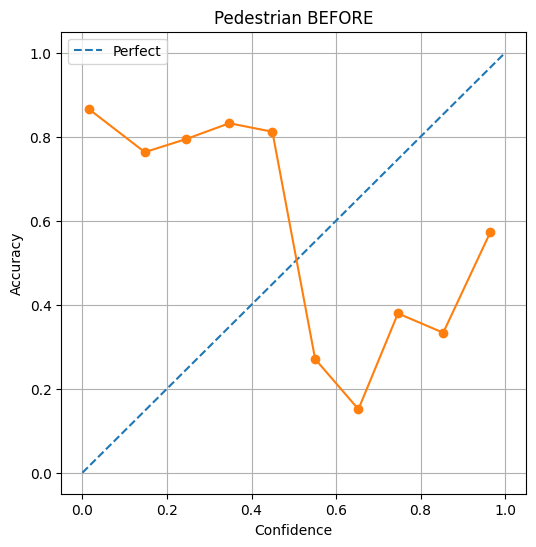

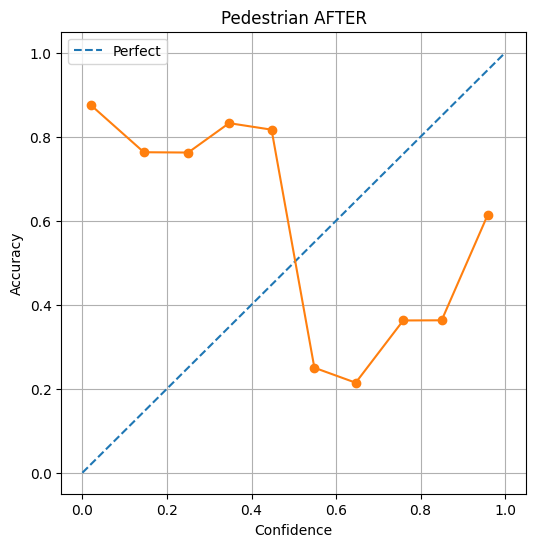

In [63]:
reliability_diagram(ped_probs, ped_labels, "Pedestrian BEFORE")
reliability_diagram(ped_probs_t, ped_labels, "Pedestrian AFTER")

In [64]:
vehicle_logits, vehicle_labels = get_logits(vehicle_model, vehicle_loader)
vehicle_probs = 1 / (1 + np.exp(-vehicle_logits))

ece_vehicle_before = compute_ece(vehicle_probs, vehicle_labels)
print("Vehicle ECE before:", ece_vehicle_before)

Vehicle ECE before: 0.18155457503058847


In [65]:
vehicle_model_t = optimize_temperature(vehicle_model, vehicle_loader, device)
T_vehicle = vehicle_model_t.temperature.item()

print("Vehicle Temperature:", T_vehicle)

Vehicle Temperature: 1.110532522201538


In [66]:
vehicle_logits_t, _ = get_logits(vehicle_model_t.model, vehicle_loader)

vehicle_probs_t = logits_to_probs(vehicle_logits_t, T_vehicle)

ece_vehicle_after = compute_ece(vehicle_probs_t, vehicle_labels)

print("Vehicle ECE after:", ece_vehicle_after)

Vehicle ECE after: 0.17704032307283746


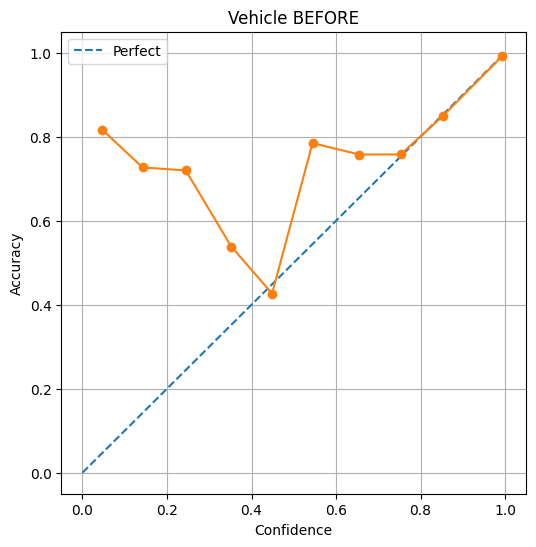

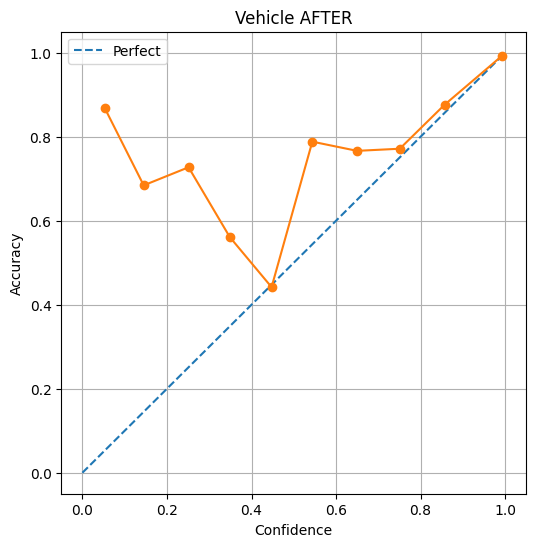

In [67]:
reliability_diagram(vehicle_probs, vehicle_labels, "Vehicle BEFORE")
reliability_diagram(vehicle_probs_t, vehicle_labels, "Vehicle AFTER")

In [68]:
traffic_logits, traffic_labels = get_logits(traffic_model, traffic_loader)
traffic_probs = 1 / (1 + np.exp(-traffic_logits))

ece_traffic_before = compute_ece(traffic_probs, traffic_labels)
print("Traffic ECE before:", ece_traffic_before)

Traffic ECE before: 0.2619261077142114


In [69]:
traffic_model_t = optimize_temperature(traffic_model, traffic_loader, device)
T_traffic = traffic_model_t.temperature.item()

print("Traffic Temperature:", T_traffic)

Traffic Temperature: 1.197595477104187


In [70]:
traffic_logits_t, _ = get_logits(traffic_model_t.model, traffic_loader)

traffic_probs_t = logits_to_probs(traffic_logits_t, T_traffic)

ece_traffic_after = compute_ece(traffic_probs_t, traffic_labels)

print("Traffic ECE after:", ece_traffic_after)

Traffic ECE after: 0.2563192929637928


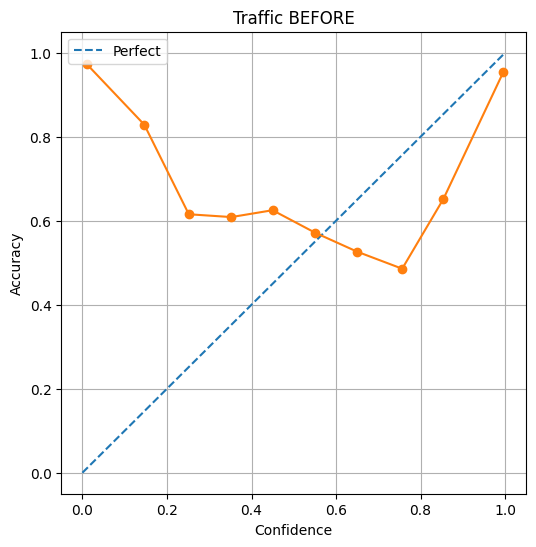

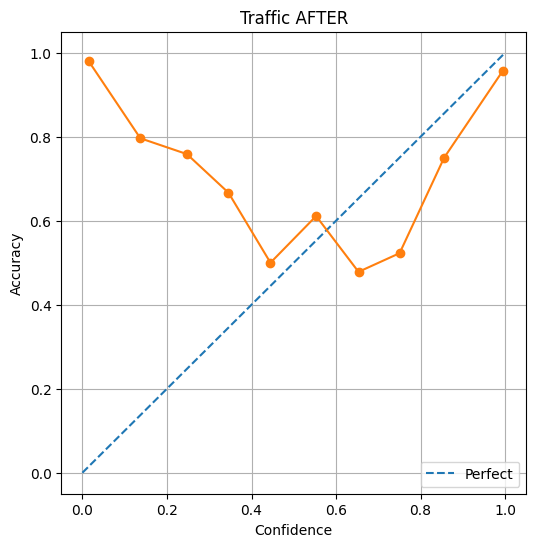

In [71]:
reliability_diagram(traffic_probs, traffic_labels, "Traffic BEFORE")
reliability_diagram(traffic_probs_t, traffic_labels, "Traffic AFTER")

In [72]:
import numpy as np
import torch
import torch.nn.functional as F

def nll_for_temperature(logits, labels, T):
    logits_T = logits / T
    loss = F.binary_cross_entropy_with_logits(
        torch.tensor(logits_T),
        torch.tensor(labels).float()
    )
    return loss.item()

In [73]:
def find_best_temperature(logits, labels, t_min=0.5, t_max=3.0, step=0.1):
    best_T = t_min
    best_nll = float("inf")

    Ts = np.arange(t_min, t_max + step, step)

    for T in Ts:
        nll = nll_for_temperature(logits, labels, T)

        if nll < best_nll:
            best_nll = nll
            best_T = T

    return best_T, best_nll

In [78]:
ped_logits, ped_labels = get_logits(ped_model, test_loader)

# BEFORE
ped_probs_before = torch.sigmoid(torch.tensor(ped_logits)).numpy()
ece_ped_before = compute_ece(ped_probs_before, ped_labels)

# FIND BEST T
best_T_ped, _ = find_best_temperature(ped_logits, ped_labels)

# AFTER
ped_probs_after = logits_to_probs(ped_logits, best_T_ped)
ece_ped_after = compute_ece(ped_probs_after, ped_labels)

print("=== PEDESTRIAN ===")
print("Best T:", best_T_ped)
print("ECE before:", ece_ped_before)
print("ECE after:", ece_ped_after)

=== PEDESTRIAN ===
Best T: 2.9999999999999996
ECE before: 0.7148425148629269
ECE after: 0.5750206926107213


In [80]:
vehicle_logits, vehicle_labels = get_logits(vehicle_model, vehicle_loader)

# BEFORE
vehicle_probs_before = torch.sigmoid(torch.tensor(vehicle_logits)).numpy()
ece_vehicle_before = compute_ece(vehicle_probs_before, vehicle_labels)

# FIND BEST T
best_T_vehicle, _ = find_best_temperature(vehicle_logits, vehicle_labels)

# AFTER
vehicle_probs_after = logits_to_probs(vehicle_logits, best_T_vehicle)
ece_vehicle_after = compute_ece(vehicle_probs_after, vehicle_labels)

print("=== VEHICLE ===")
print("Best T:", best_T_vehicle)
print("ECE before:", ece_vehicle_before)
print("ECE after:", ece_vehicle_after)

=== VEHICLE ===
Best T: 1.4
ECE before: 0.18155458019942874
ECE after: 0.172351281527572


In [81]:
traffic_logits, traffic_labels = get_logits(traffic_model, traffic_loader)

# BEFORE
traffic_probs_before = torch.sigmoid(torch.tensor(traffic_logits)).numpy()
ece_traffic_before = compute_ece(traffic_probs_before, traffic_labels)

# FIND BEST T
best_T_traffic, _ = find_best_temperature(traffic_logits, traffic_labels)

# AFTER
traffic_probs_after = logits_to_probs(traffic_logits, best_T_traffic)
ece_traffic_after = compute_ece(traffic_probs_after, traffic_labels)

print("=== TRAFFIC LIGHT ===")
print("Best T:", best_T_traffic)
print("ECE before:", ece_traffic_before)
print("ECE after:", ece_traffic_after)

=== TRAFFIC LIGHT ===
Best T: 1.9999999999999996
ECE before: 0.26192610813641093
ECE after: 0.2236824503582666


In [82]:
def cost_loss(probs, labels, threshold, cfn=100, cfp=1):
    preds = (probs >= threshold).astype(int)
    labels = labels.astype(int)

    fn = np.sum((preds == 0) & (labels == 1))
    fp = np.sum((preds == 1) & (labels == 0))

    return cfn * fn + cfp * fp, fn, fp

In [83]:
ped_logits, ped_labels = get_logits(ped_model, test_loader)

ped_probs_uncal = 1 / (1 + np.exp(-ped_logits))

In [84]:
ped_probs_cal = logits_to_probs(ped_logits, best_T_ped)

In [85]:
tau_1 = 0.5
tau_star = 0.0099

In [86]:
loss_uncal_05, fn1, fp1 = cost_loss(ped_probs_uncal, ped_labels, tau_1)
loss_uncal_star, fn2, fp2 = cost_loss(ped_probs_uncal, ped_labels, tau_star)

In [87]:
loss_cal_05, fn3, fp3 = cost_loss(ped_probs_cal, ped_labels, tau_1)
loss_cal_star, fn4, fp4 = cost_loss(ped_probs_cal, ped_labels, tau_star)

In [88]:
import pandas as pd

table = pd.DataFrame(
    {
        "τ = 0.5": [loss_uncal_05, loss_cal_05],
        "τ = τ*": [loss_uncal_star, loss_cal_star]
    },
    index=["Uncalibrated", "Calibrated"]
)

print(table)

              τ = 0.5  τ = τ*
Uncalibrated    45169   18664
Calibrated      45169    2889
